## Label clustering


### Load files

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import umap
import hdbscan
from scipy import stats
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.utils import resample
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
import collections
from itertools import combinations


In [2]:
# Define the root file name (without extension or suffixes)
date= "26.02.10"
file_name_root1 = "mask_intersect_1"
# Read the CSV file with cell features
data_file = f"{date}_{file_name_root1}_properties_quantitative.csv"
cell_features = pd.read_csv(data_file)
df_props1 = pd.DataFrame(cell_features)

In [3]:
# Define the root file name (without extension or suffixes)
file_name_root2 = "mask_intersect_2"
# Read the CSV file with cell features
data_file = f"{date}_{file_name_root2}_properties_quantitative.csv"
cell_features = pd.read_csv(data_file)
df_props2 = pd.DataFrame(cell_features)

In [4]:
# Define the root file name (without extension or suffixes)
file_name_root3 = "mask_intersect_3"
# Read the CSV file with cell features
data_file = f"{date}_{file_name_root3}_properties_quantitative.csv"
cell_features = pd.read_csv(data_file)
df_props3 = pd.DataFrame(cell_features)

In [5]:
# Define the root file name (without extension or suffixes)
file_name_root4 = "mask_intersect_4"
# Read the CSV file with cell features
data_file = f"{date}_{file_name_root4}_properties_quantitative.csv"
cell_features = pd.read_csv(data_file)
df_props4 = pd.DataFrame(cell_features)

In [6]:
# Define the root file name (without extension or suffixes)
file_name_root5 = "mask_intersect_5"
# Read the CSV file with cell features
data_file = f"{date}_{file_name_root5}_properties_quantitative.csv"
cell_features = pd.read_csv(data_file)
df_props5 = pd.DataFrame(cell_features)

### Unify information



In [7]:
# Unify the source column for each DataFrame to indicate the origin of the data
df_props1['source'] = file_name_root1
df_props2['source'] = file_name_root2
df_props3['source'] = file_name_root3
df_props4['source'] = file_name_root4
df_props5['source'] = file_name_root5
# Create an new DataFrame to store all the results
df_props = pd.DataFrame()
df_props = pd.concat([df_props1, df_props2, df_props3, df_props4, df_props5], ignore_index=True)

In [8]:
# Verify the number of rows in the combined DataFrame
print(len(df_props))
print(len(df_props1)+len(df_props2)+len(df_props3)+len(df_props4)+len(df_props5)) # the sum of the number of rows in each individual DataFrame
print(len(df_props[['label', 'source']].drop_duplicates())) # the number of unique combinations of label and source

print(df_props[['label', 'source']].head())

3122
3122
3122
   label            source
0      1  mask_intersect_1
1      2  mask_intersect_1
2      5  mask_intersect_1
3      6  mask_intersect_1
4      7  mask_intersect_1


## Analyze data

In [9]:
print(f"Mean apical neighbors: {df_props['apical_neighbors_n'].mean()}")
print(f"Mean basal neighbors: {df_props['basal_neighbors_n'].mean()}")
print(f"Mean 3-D neighbors: {df_props['3D_neighbors_n'].mean()}")

print(f"Scutoid percentage: {df_props['potential_scutoid'].mean() * 100}%")

Mean apical neighbors: 5.735105701473414
Mean basal neighbors: 5.730301089045484
Mean 3-D neighbors: 6.046124279308136
Scutoid percentage: 46.63677130044843%


In [10]:
print(df_props.columns)

len(df_props.columns)

Index(['label', 'centroid_cell_z_norm_um', 'height_um', 'area_apical_um2',
       'area_basal_um2', 'logratio_ap_bas', 'shape_index_apical',
       'shape_index_basal', 'dif_shape_index', 'dif_area', 'aspect_ratio',
       'volume_um3', 'surface_um2', 'sphericity', 'elongation', 'angle_z',
       'curvature_apical_tisular_mean', 'curvature_apical_celular_mean',
       'curvature_basal_tisular_inv_mean', 'curvature_basal_celular_inv_mean',
       'apical_neighbors_n', 'basal_neighbors_n', 'dif_neighbors',
       'potential_scutoid', '3D_neighbors_n', 'local_density_apical',
       'local_density_basal', 'source'],
      dtype='str')


28

## CLUSTERING

In [11]:
df_props_filt = df_props.copy() #create a copy of the DataFrame to filter out unnecessary columns

#df_props_filt.drop(columns=['label','potential_scutoid','source'], inplace=True, errors='ignore')

df_props_filt.drop(columns=['label',
                            'centroid_cell_z_norm_um',
                            #'aspect_ratio',
                            #'elongation',
                            #'angle_z',
                            'potential_scutoid',
                            'apical_neighbors_n', 'basal_neighbors_n',
                            #'dif_neighbors', 
                            # 'dif_shape_index',
                            # 'dif_area',
                            # 'logratio_ap_bas',
                            'source','kmeans_cluster'], inplace=True,
                     errors='ignore')

print(df_props_filt.columns)
print(len(df_props_filt.columns))

Index(['height_um', 'area_apical_um2', 'area_basal_um2', 'logratio_ap_bas',
       'shape_index_apical', 'shape_index_basal', 'dif_shape_index',
       'dif_area', 'aspect_ratio', 'volume_um3', 'surface_um2', 'sphericity',
       'elongation', 'angle_z', 'curvature_apical_tisular_mean',
       'curvature_apical_celular_mean', 'curvature_basal_tisular_inv_mean',
       'curvature_basal_celular_inv_mean', 'dif_neighbors', '3D_neighbors_n',
       'local_density_apical', 'local_density_basal'],
      dtype='str')
22


In [12]:
# Feature scaling

scaler = StandardScaler() # standardize features by removing the mean and scaling to unit variance
X= df_props_filt.dropna()
X_sc = scaler.fit_transform(X)

### UMAP

In [ ]:
# Perform a grid search over UMAP and HDBSCAN parameters to find the best combination based on silhouette score

from sklearn.metrics import silhouette_score

resultados = []
for n_neighbors in [15, 30, 50]:
    for min_cluster_size in [30, 50, 100]:
        reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=0.01, random_state=42)
        X_test = reducer.fit_transform(X_sc)

        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=max(5, min_cluster_size//4))
        labels_test = clusterer.fit_predict(X_test)

        n_clust = len(set(labels_test)) - (1 if -1 in labels_test else 0)
        n_noise = (labels_test == -1).sum()

        if n_clust >= 2:
            mask_valid = labels_test != -1
            sil = silhouette_score(X_test[mask_valid], labels_test[mask_valid]) if mask_valid.sum() > 1 else np.nan
        else:
            sil = np.nan

        resultados.append({
            'n_neighbors': n_neighbors,
            'min_cluster_size': min_cluster_size,
            'n_clusters': n_clust,
            'n_noise': n_noise,
            'silhouette': sil,
        })

df_resultados = pd.DataFrame(resultados)
print(df_resultados.sort_values('silhouette', ascending=False))

c:\Users\USUARIO\miniconda3\envs\mask_analysis311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Clusters found: 2  |  Noise points (-1): 60


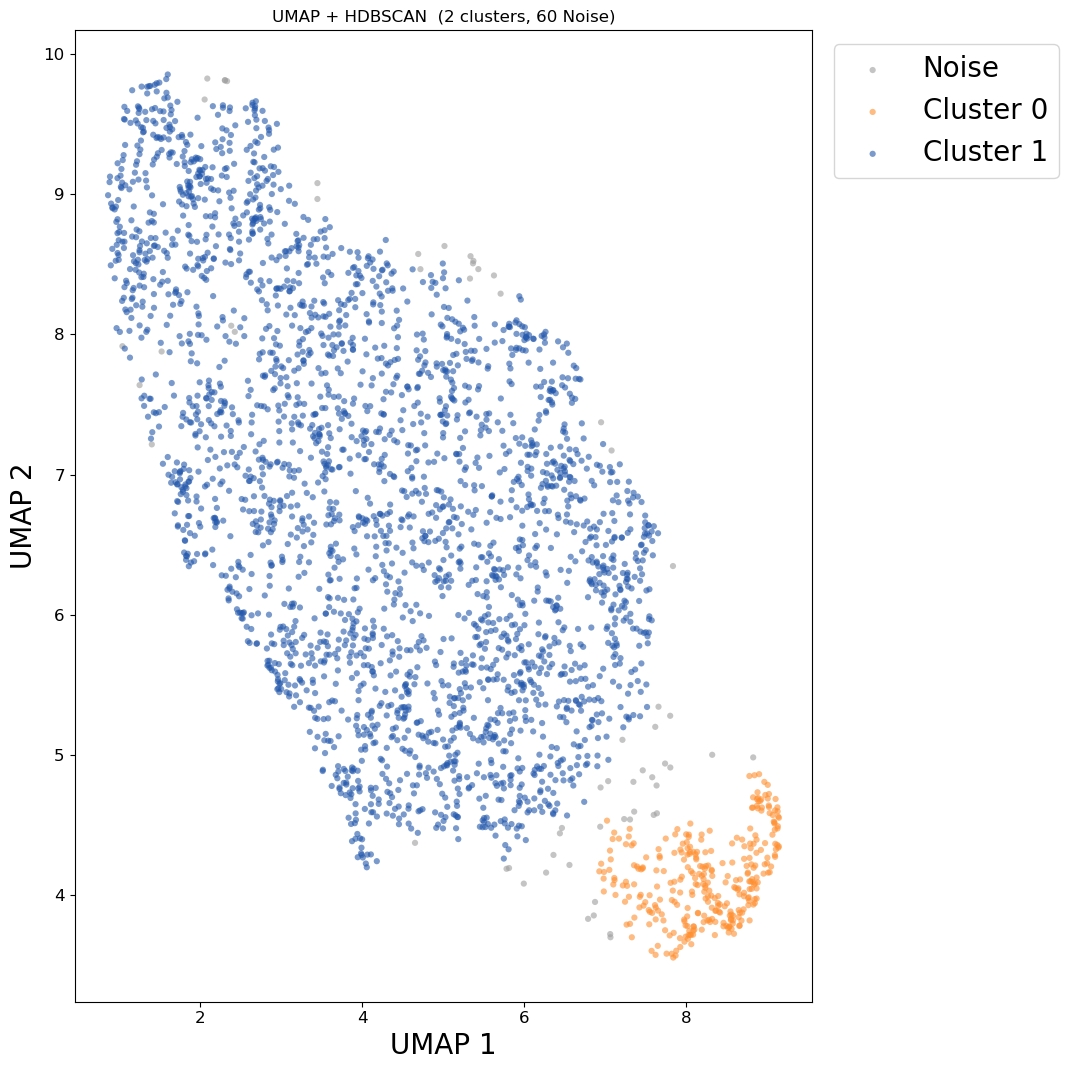

In [13]:
# UMAP: dimensionality reduction for visualization and clustering
reducer = umap.UMAP(
    n_components=2, #3  # number of dimensions for the embedding
    n_neighbors=30, #15 #50 #100    # increase = more global, decrease = more local
    min_dist=0.01, #0.1 #0.5      # compactation of points in the embedding
    metric='euclidean',
    random_state=42)

X_umap = reducer.fit_transform(X_sc)   # X = original features scaled

# HDBSCAN: clustering algorithm
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=100, #30 #50  # minimum size of clusters (affects fragmentation)
    min_samples=15, #50 #30     # minimum number of points to be considered a core point (affects noise)
    cluster_selection_method='eom')   # 'eom' smaller fragmentation, 'leaf' larger fragmentation

hdb_labels = clusterer.fit_predict(X_umap)

n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise    = (hdb_labels == -1).sum()
print(f'Clusters found: {n_clusters}  |  Noise points (-1): {n_noise}')

# Save the UMAP coordinates and HDBSCAN labels to a new DataFrame for further analysis
df_props_umap = X.copy()
df_props_umap['hdbscan_cluster'] = hdb_labels #for further analysis, add the cluster labels to the DataFrame

# For image visualization, we need to keep the original labels and source information, so we create a new DataFrame that drops any rows with missing values in the original DataFrame
df_props_source =df_props.dropna() # el original, para conservar labels y source
df_props_source['hdbscan_cluster'] = hdb_labels
df_props_source[['label', 'source', 'hdbscan_cluster']].to_csv(f"{date}_all_clusters_umap.csv", index=False)

# Cluster visualization using UMAP coordinates and HDBSCAN labels
fig, ax = plt.subplots(figsize=(1080/100, 1080/100), dpi=100)

unique_labels = sorted(set(hdb_labels))
noise_cmap = ListedColormap(["#9e9e9e"])  # Color for noise points
cmap = ListedColormap(["#FE8E2F","#2257ab","#f7c331","#4caf50","#e91e63","#9c27b0","#00bcd4","#ff5722","#8bc34a","#3f51b5","#ffc107","#673ab7","#2196f3","#ff9800"])

for label in unique_labels:
    mask  = hdb_labels == label
    color = noise_cmap(0) if label == -1 else cmap(label % cmap.N)
    name  = 'Noise' if label == -1 else f'Cluster {label}'
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               c=[color], s=20, alpha=0.6,
               edgecolors='none', label=name)

ax.set_xlabel('UMAP 1', fontsize=20)
ax.set_ylabel('UMAP 2', fontsize=20)
ax.tick_params(axis='both', labelsize=12)
ax.set_title(f'UMAP + HDBSCAN  ({n_clusters} clusters, {n_noise} Noise)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=20)

plt.tight_layout()
fig.savefig(fname= f'{date}_clusters_umap.jpg',dpi=100,format='jpeg',bbox_inches='tight',pil_kwargs={'quality': 95})
plt.show()

In [14]:
# Bootstrap resampling to assess the stability of clustering results
mask_valid = hdb_labels != -1 #ignore noise (-1)
n_boot  = 1000
overlap = []

for _ in range(n_boot):
    idx     = resample(np.arange(len(X_umap[mask_valid])), random_state=None)
    X_boot  = X_umap[mask_valid][idx]
    labs    = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10).fit_predict(X_boot)
    n_c     = len(set(labs)) - (1 if -1 in labs else 0)
    overlap.append(n_c)


print("Distribución de k en bootstrap:", collections.Counter(overlap)) #THERE'S A STABLE SEPARATION BETWEEN CELL CLUSTERS

Distribución de k en bootstrap: Counter({2: 991, 3: 8, 4: 1})


In [15]:
# Evaluate clustering quality using silhouette score, Davies-Bouldin index, and Calinski-Harabasz index
# Ignore noise (-1)
mask_valid = hdb_labels != -1
X_eval     = X_umap[mask_valid]
y_eval     = hdb_labels[mask_valid]

print(f"Silhouette:          {silhouette_score(X_eval, y_eval):.3f}")   # [-1,1], the higher the better
print(f"Davies-Bouldin:      {davies_bouldin_score(X_eval, y_eval):.3f}")  # [0,∞), the lower the better
print(f"Calinski-Harabasz:   {calinski_harabasz_score(X_eval, y_eval):.1f}")  # the higher the better

Silhouette:          0.418
Davies-Bouldin:      0.533
Calinski-Harabasz:   1520.3


In [ ]:
# Cluster visualization — categorical (source, potential_scutoid, dif_neighbors) + numerical features
fig = plt.figure(figsize=(2048/100, (512 + 2048)/100), dpi=100)
gs  = fig.add_gridspec(5, 3, height_ratios=[1, 1, 1, 1, 1])

# Categorical variables (source, potential_scutoid, dif_neighbors)
cat_cols = ['source', 'potential_scutoid', 'dif_neighbors']

for j, col in enumerate(cat_cols):
    ax = fig.add_subplot(gs[0, j])
    cats = df_props.loc[X.index, col].astype('category')
    for i, cat in enumerate(cats.cat.categories):
        mask = cats == cat
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                   s=18, alpha=0.6, edgecolors='none',
                   label=str(cat), color=plt.cm.tab10.colors[i % 10])
    ax.set_title(col)
    ax.set_xlabel('UMAP 1', fontsize=20)
    ax.set_ylabel('UMAP 2', fontsize=20)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)

# Numerical variables (biological properties)
cols_bio = ['height_um', 'aspect_ratio', 'sphericity', 'angle_z',
            'local_density_apical', 'curvature_apical_tisular_mean', 'curvature_apical_celular_mean',
            'area_apical_um2', 'volume_um3', 'surface_um2', 'elongation', '3D_neighbors_n']

positions = [(r, c) for r in range(1, 5) for c in range(3)]

for (r, c), col in zip(positions, cols_bio):
    ax = fig.add_subplot(gs[r, c])
    vals = df_props.loc[X.index, col].values

    sc = ax.scatter(X_umap[:, 0], X_umap[:, 1],
                     c=vals, cmap='viridis', s=6, alpha=0.5, edgecolors='none')

    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(col)

    ax.set_title(col)
    ax.set_xlabel('UMAP 1', fontsize=20)
    ax.set_ylabel('UMAP 2', fontsize=20)

plt.tight_layout()
fig.savefig(fname=f'{date}_clusters_umap_combined.jpg', dpi=100, format='jpeg', bbox_inches='tight', pil_kwargs={'quality': 95})
plt.show()

In [ ]:
# Average the biological properties for each cluster to understand their characteristics
df_props_umap.groupby('hdbscan_cluster').mean()

In [ ]:
# Radar plot to compare the average properties of clusters, normalized against the global min/max of the original DataFrame

# Average the biological properties for each cluster to understand their characteristics
means = df_props_umap.groupby('hdbscan_cluster').mean()
means = means.loc[[0, 1]]

cols_radar = [
    # Cell orientation
    'elongation',
    'angle_z',
    # Size
    'height_um',
    'volume_um3',
    'surface_um2',
    # Apicobasal geometry
    'area_apical_um2',
    'area_basal_um2',
    'logratio_ap_bas',
    'dif_area',
    'dif_shape_index',
    # Shape
    'shape_index_apical',
    'shape_index_basal',
    'sphericity',
    'aspect_ratio',
    # Tisular organization
    'local_density_apical',
    'local_density_basal',
    '3D_neighbors_n',
    'dif_neighbors',
    # Tisular curvature
    'curvature_apical_tisular_mean',
    'curvature_basal_tisular_inv_mean',
    # Cellular curvature
    'curvature_apical_celular_mean',
    'curvature_basal_celular_inv_mean']

means_radar = means[cols_radar]

# Normalize means to the global 1 and 99 percentiles of the original DataFrame. Allows robust comparison omitting outliers
global_min = df_props[cols_radar].quantile(0.01)
global_max = df_props[cols_radar].quantile(0.99)
means_norm = (means_radar - global_min) / (global_max - global_min)

# Radar plot
categories = cols_radar
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

custom_colors = ["#FE8E2F","#2257ab","#f7c331","#4caf50","#e91e63","#9c27b0","#00bcd4","#ff5722","#8bc34a","#3f51b5","#ffc107","#673ab7","#2196f3","#ff9800"]

fig, ax = plt.subplots(figsize=(2048/100, 1024/100), dpi=100, subplot_kw=dict(polar=True))

# Cluster -1 (noise) usa el índice 0, el resto usa label+1 para coincidir con la paleta de HDBSCAN
colors = [custom_colors[0] if cid == -1 else custom_colors[(cid) % len(custom_colors)] 
          for cid in means_norm.index]

for i, cluster_id in enumerate(means_norm.index):
    values = means_norm.loc[cluster_id].tolist()
    values += values[:1]
    name = 'Noise' if cluster_id == -1 else f'Cluster {cluster_id}'
    ax.plot(angles, values, linewidth=2, label=name, color=colors[i])
    ax.fill(angles, values, alpha=0.15, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10, color='white')
ax.set_ylim(0, 1)
ax.set_yticklabels([])
ax.set_title('Cluster comparisons normalized', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=20)

plt.tight_layout()
fig.savefig(fname=f'{date}_radar_plot.jpg', dpi=100, format='jpeg', bbox_inches='tight', pil_kwargs={'quality': 95})
plt.show()

In [ ]:
# Seems obvious: the variables used to define the clusters are also the ones that show the most significant differences between them.

def effect_to_stars(r):
    if r >= 0.8:   return '***'
    elif r >= 0.5: return '**'
    elif r >= 0.3: return '*'
    else:          return 'ns'

# Comparison between cluster pairs using Mann-Whitney U test and effect size calculation
unique_labels = sorted(df_props_umap['hdbscan_cluster'].unique())
cols_num      = [c for c in df_props_umap.columns if c != 'hdbscan_cluster']

all_rows = []

for cluster1, cluster2 in combinations(unique_labels, 2):
    mask1 = df_props_umap['hdbscan_cluster'] == cluster1
    mask2 = df_props_umap['hdbscan_cluster'] == cluster2

    rows = []
    for col in cols_num:
        a = df_props_umap.loc[mask1, col].dropna()
        b = df_props_umap.loc[mask2, col].dropna()

        if len(a) < 3 or len(b) < 3:
            continue

        result = stats.mannwhitneyu(a, b, alternative='two-sided')
        r      = 1 - (2 * result.statistic) / (len(a) * len(b))

        rows.append({
            'feature'   : col,
            'cluster_1' : cluster1,
            'cluster_2' : cluster2,
            'mean_c1'   : round(a.mean(), 4),
            'std_c1'    : round(a.std(), 4),
            'mean_c2'   : round(b.mean(), 4),
            'std_c2'    : round(b.std(), 4),
            'p_mw'      : result.pvalue,
            'effect_r'  : round(abs(r), 3),
        })

    if not rows:
        continue

    df_pair = pd.DataFrame(rows).set_index('feature')

    #rejected, p_adj, _, _ = multipletests(df_pair['p_mw'], method='fdr_bh') # Benjamini-Hochberg
    rejected, p_adj, _, _ = multipletests(df_pair['p_mw'], method='bonferroni') # Bonferroni
    df_pair['p_adj']      = p_adj.round(4)
    df_pair['p_mw']           = df_pair['p_mw'].round(4)
    df_pair['sig']             = rejected
    df_pair['sust_sig']        = df_pair['sig'] & (df_pair['effect_r'] >= 0.3)
    df_pair['stars_combined']  = df_pair.apply(
        lambda row: effect_to_stars(row['effect_r']) if (row['sig'] and row['effect_r'] >= 0.1) else 'ns',
        axis=1
    )

    all_rows.append(df_pair)
    print(f"\n── Cluster {cluster1} vs Cluster {cluster2} ──")
    print(df_pair[['cluster_1', 'cluster_2', 'mean_c1', 'mean_c2',
                   'effect_r', 'p_adj', 'sig', 'sust_sig', 'stars_combined']].to_string())

df_mw_clusters = pd.concat(all_rows)